In [1]:
import numpy as np
from IPython.display import display, Math, Markdown
from scipy.special import comb, factorial


# Индивидуальное задание

## Условия

N = 3 - сколько типов процессоров

m_1 = 2 - сколько процессоров 1 типа

m_2 = 1 - сколько процессоров 2 типа

m_3 = 1 - сколько процессоров 3 типа

n = 3 - сколько шин, спсобов передачи даннных

T_о1 = 1.2 - время выполнеия операции процом 1 типа

T_02 = 9

T_03 = 48

Tau_1 = 1.33 - интенсивность обслуживания для 1 процессора

Tau_2 = 1.33 - интенсивность обслуживания для 2 процессора

Tau_3 = 1.33 - интенсивность обслуживания для 3 процессора

q = 0.35 - параметр связанности алгоритма по памяти

In [2]:
N = 3
m1, m2, m3 = 2, 1, 1
n = 3
To1, To2, To3 = 1.2, 9, 48
tau1, tau2, tau3 = 1.33, 1.33, 1.33
q = 0.35

In [3]:
v1 = (q/n) / (To1 - (q/n)*tau1)
v2 = (q/n) / (To2 - (q/n)*tau2)
v3 = (q/n) / (To3 - (q/n)*tau3)
mu1 = 1/tau1
mu2 = 1/tau2
mu3 = 1/tau3

rho1 = v1/mu1
rho2 = v2/mu2
rho3 = v3/mu3

display(Markdown(rf"* $\nu_1 = {v1}$"))
display(Markdown(rf"* $\nu_2 = {v2}$"))
display(Markdown(rf"* $\nu_3 = {v3}$"))
display(Markdown(rf"* $\mu_1 = {mu1}$"))
display(Markdown(rf"* $\mu_2 = {mu2}$"))
display(Markdown(rf"* $\mu_3 = {mu3}$"))

* $\nu_1 = 0.11166055192215664$

* $\nu_2 = 0.013190374795078104$

* $\nu_3 = 0.0024384381455329553$

* $\mu_1 = 0.7518796992481203$

* $\mu_2 = 0.7518796992481203$

* $\mu_3 = 0.7518796992481203$

Условие стационарного режима:

$\forall i: \rho_i = \frac{\nu_i}{\mu_i} \le 1$

In [4]:
ro1 = v1/mu1
ro2 = v2/mu2
ro3 = v3/mu3
display(Markdown(rf"* $\rho_1 = {ro1} \le 1$"))
display(Markdown(rf"* $\rho_2 = {ro2} \le 1$"))
display(Markdown(rf"* $\rho_3 = {ro3} \le 1$"))

* $\rho_1 = 0.14850853405646833 \le 1$

* $\rho_2 = 0.017543198477453878 \le 1$

* $\rho_3 = 0.0032431227335588306 \le 1$

Стационарный режим выполняется

## Граф состояний

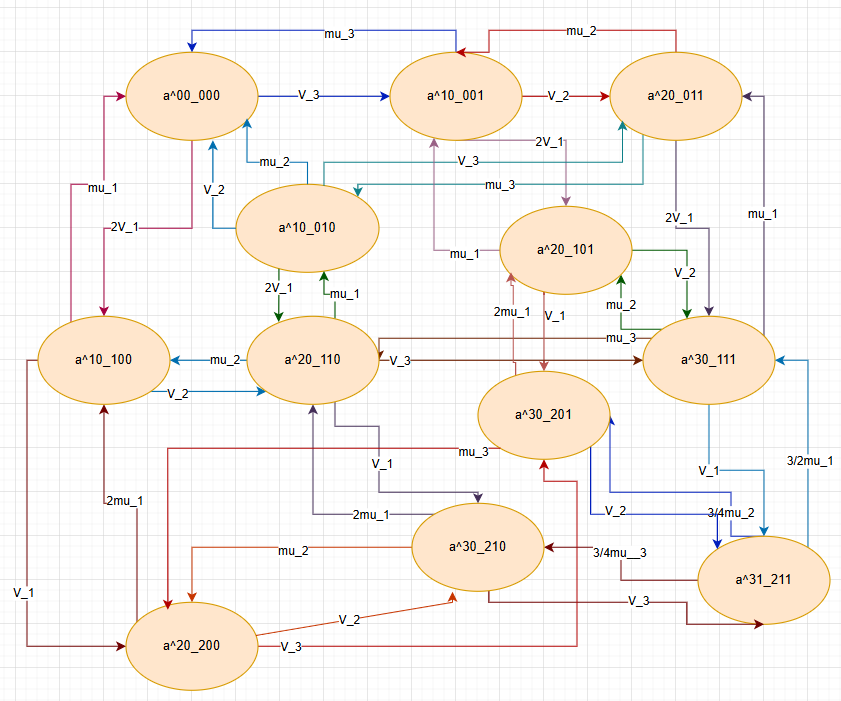

## Решение СЛАУ, поиск вероятности состояний

Система в виде $A \cdot X=B$.

In [5]:
A = [
      [-(2*v1+v2+v3),  mu1,                  mu2,                  mu3,                  0,                         0,                         0,                         0,                         0,                         0,                         0,                         0],
      [2*v1,           -(mu1+v1+v2+v3),      0,                    0,                    2*mu1,                     mu2,                       mu3,                       0,                         0,                         0,                         0,                         0],
      [v2,             0,                    -(mu2+2*v1+v3),       0,                    0,                         mu1,                       0,                         mu3,                       0,                         0,                         0,                         0],
      [v3,             0,                    0,                    -(mu3+2*v1+v2),       0,                         0,                         mu1,                       mu2,                       0,                         0,                         0,                         0],
      [0,              v1,                   0,                    0,                    -(2*mu1+v2+v3),            0,                         0,                         0,                         mu2,                      mu3,                      0,                         0],
      [0,              v2,                   2*v1,                 0,                    0,                         -(mu1+mu2+v1+v3),          0,                         0,                         2*mu1,                    0,                         mu3,                      0],
      [0,              v3,                   0,                    2*v1,                 0,                         0,                         -(mu1+mu3+v1+v2),          0,                         0,                         2*mu1,                    mu2,                      0],
      [0,              0,                    v3,                   v2,                   0,                         0,                         0,                         -(mu2+mu3+2*v1),          0,                         0,                         mu1,                      0],
      [0,              0,                    0,                    0,                    v2,                        v1,                        0,                         0,                         -(2*mu1+mu2+v3),          0,                         0,                         3*mu3/4],
      [0,              0,                    0,                    0,                    v3,                        0,                         v1,                        0,                         0,                         -(2*mu1+mu3+v2),          0,                         3*mu2/4],
      [0,              0,                    0,                    0,                    0,                         v3,                        v2,                        2*v1,                     0,                         0,                         -(mu1+mu2+mu3+v1),        3*mu1/2],
      [0,              0,                    0,                    0,                    0,                         0,                         0,                         0,                         v3,                        v2,                        v1,                        -(3*mu1/2+3*mu2/4+3*mu3/4)]
     ]

In [6]:
A = np.array(A)

In [7]:
np.set_printoptions(linewidth=150)
print(A)

[[-0.23894992  0.7518797   0.7518797   0.7518797   0.          0.          0.          0.          0.          0.          0.          0.        ]
 [ 0.2233211  -0.87916906  0.          0.          1.5037594   0.7518797   0.7518797   0.          0.          0.          0.          0.        ]
 [ 0.01319037  0.         -0.97763924  0.          0.          0.7518797   0.          0.7518797   0.          0.          0.          0.        ]
 [ 0.00243844  0.          0.         -0.98839118  0.          0.          0.7518797   0.7518797   0.          0.          0.          0.        ]
 [ 0.          0.11166055  0.          0.         -1.51938821  0.          0.          0.          0.7518797   0.7518797   0.          0.        ]
 [ 0.          0.01319037  0.2233211   0.          0.         -1.61785839  0.          0.          1.5037594   0.          0.7518797   0.        ]
 [ 0.          0.00243844  0.          0.2233211   0.          0.         -1.62861033  0.          0.          1.50375

Одно из уравнений нужно заменить на условие нормировки.

$P_{000}^{00}+P_{100}^{10}+P_{010}^{10}+P_{001}^{10}+P_{200}^{20}+P_{110}^{20}+P_{101}^{20}+P_{011}^{20}+P_{210}^{30}+P_{201}^{30}+P_{111}^{30}+P_{211}^{31} = 1$

In [8]:
eq_num = 5
A[eq_num] = [1,1,1,1,1,1,1,1,1,1,1, 1]

In [9]:
print(A)

[[-0.23894992  0.7518797   0.7518797   0.7518797   0.          0.          0.          0.          0.          0.          0.          0.        ]
 [ 0.2233211  -0.87916906  0.          0.          1.5037594   0.7518797   0.7518797   0.          0.          0.          0.          0.        ]
 [ 0.01319037  0.         -0.97763924  0.          0.          0.7518797   0.          0.7518797   0.          0.          0.          0.        ]
 [ 0.00243844  0.          0.         -0.98839118  0.          0.          0.7518797   0.7518797   0.          0.          0.          0.        ]
 [ 0.          0.11166055  0.          0.         -1.51938821  0.          0.          0.          0.7518797   0.7518797   0.          0.        ]
 [ 1.          1.          1.          1.          1.          1.          1.          1.          1.          1.          1.          1.        ]
 [ 0.          0.00243844  0.          0.2233211   0.          0.         -1.62861033  0.          0.          1.50375

In [10]:
B = np.array([0,0,0,0,0,0,0,0,0,0,0, 0])
B[eq_num] = 1
print("B =",B)

B = [0 0 0 0 0 1 0 0 0 0 0 0]


Решение уравнения стандартным инструментом из numpy

In [11]:
P = np.linalg.solve(A,B)
P_names = ['$P_{000}^{00}$', '$P_{100}^{10}$',
  '$P_{010}^{10}$', '$P_{001}^{10}$', '$P_{200}^{20}$',
  '$P_{110}^{20}$', '$P_{101}^{20}$', '$P_{011}^{20}$',
  '$P_{210}^{30}$', '$P_{201}^{30}$', '$P_{111}^{30}$',
  '$P_{211}^{31}$']
for i in range(11):
  display(Markdown(rf"{P_names[i]} = %.6f"%P[i]))
    
ver=0
for i in range(11):
  ver+=P[i]
print (ver)

$P_{000}^{00}$ = 0.742630

$P_{100}^{10}$ = 0.220574

$P_{010}^{10}$ = 0.013028

$P_{001}^{10}$ = 0.002408

$P_{200}^{20}$ = 0.016379

...

$P_{011}^{20}$ = 0.000042

$P_{210}^{30}$ = 0.000287

$P_{201}^{30}$ = 0.000053

$P_{111}^{30}$ = 0.000013

0.9999987575295025


## Оценка производительности

Совокупные вероятности:

$P_{00} = P_{000}^{00}$

$P_{10} = P_{100}^{10} + P_{010}^{10} + P_{001}^{10}$

$P_{20} = P_{200}^{20} + P_{110}^{20} + P_{101}^{20} + P_{011}^{20}$

$P_{30} = P_{210}^{30} + P_{201}^{30} + P_{111}^{30}$

$P_{31} = P_{211}^{31}$

In [12]:
P00 = P[0]
P10 = P[1]+P[2]+P[3]
P20 = P[4]+P[5]+P[6]+P[7]
P30 = P[8]+P[9]+P[10]
P31 = P[11]

Средняя длина очереди:

$l_{ср} = \sum{l \cdot P_{l,k}}$

$l_{ср} = 0 \cdot P_{0,0} + 0 \cdot P_{1,0} + 0 \cdot P_{2,0} + 0 \cdot P_{3,0} + 1 \cdot P_{3,1}$

In [13]:
l = 0*P00 + 0*P10 + 0*P20 + 0*P30 + 1*P31
display(Markdown(r"$l_{ср}$ = %.6f"%l))

$l_{ср}$ = 0.000001

Относительная потеря производительности:

$ \theta_i = 1 + \frac{l_{ср}\tau_i}{T_{oi}+\tau_i}$

In [14]:
theta1 = 1 + (l*tau1)/(To1+tau1)
theta2 = 1 + (l*tau2)/(To2+tau2)
theta3 = 1 + (l*tau3)/(To1+tau3)
display(Markdown(r"$\theta_1$ = %.8f"%theta1))
display(Markdown(r"$\theta_2$ = %.8f"%theta2))
display(Markdown(r"$\theta_3$ = %.8f"%theta3))

$\theta_1$ = 1.00000065

$\theta_2$ = 1.00000016

$\theta_3$ = 1.00000065

Производительность:

$ П_{ср} = \sum{\frac{m_i}{\theta_i}}$

In [15]:
Performance = m1/theta1 + m2/theta2 + m3/theta3
display(Markdown(r"$П_{ср}$ = %.5f"%Performance))

$П_{ср}$ = 4.00000

In [16]:
import numpy as np
import pandas as pd
from itertools import product
from math import comb, factorial
from IPython.display import display, Markdown

m_direct = [m1, m2, m3]
n_direct = n
N_direct = len(m_direct)
M_direct = sum(m_direct)
h_direct = min(M_direct, n_direct)

rho_direct = [v1 / mu1, v2 / mu2, v3 / mu3]


def terskov_weight(j, k, l, m, n, rho):
    s = sum(j)

    if s == 0:
        return 1.0 if k == 0 and l == 0 else 0.0

    if s != k + l:
        return 0.0

    if k < 1 or k > min(s, n):
        return 0.0

    if l < 0:
        return 0.0

    w = 1.0

    w *= comb(k + l - 1, l)
    w *= comb(n, k)
    w *= 1 / (n ** (k + l))

    w *= factorial(k + l)

    for ji in j:
        w /= factorial(ji)

    for i, ji in enumerate(j):
        w *= factorial(m[i]) / factorial(m[i] - ji)
        w *= rho[i] ** ji

    return w


def p_label(j, k, l):
    lower = "".join(str(x) for x in j)
    return rf"$P_{{{lower}}}^{{{k}{l}}}$"


def graph_label(j):
    s = sum(j)
    h = min(s, n_direct)
    l = s - h
    lower = "".join(str(x) for x in j)
    return rf"$P_{{{lower}}}^{{{h}{l}}}$"


# Полное пространство состояний по формуле со слайда

rows = []

rows.append({
    "j": (0, 0, 0),
    "k": 0,
    "l": 0,
    "state": p_label((0, 0, 0), 0, 0),
    "weight": 1.0
})

for k in range(1, h_direct + 1):
    for l in range(0, M_direct - k + 1):
        s = k + l

        for j in product(*[range(mi + 1) for mi in m_direct]):
            if sum(j) == s:
                w = terskov_weight(j, k, l, m_direct, n_direct, rho_direct)

                if w > 0:
                    rows.append({
                        "j": j,
                        "k": k,
                        "l": l,
                        "state": p_label(j, k, l),
                        "weight": w
                    })

df_direct_full = pd.DataFrame(rows)

Z = df_direct_full["weight"].sum()
df_direct_full["P_direct"] = df_direct_full["weight"] / Z

graph_states = [
    (0, 0, 0),
    (1, 0, 0),
    (0, 1, 0),
    (0, 0, 1),
    (2, 0, 0),
    (1, 1, 0),
    (1, 0, 1),
    (0, 1, 1),
    (2, 1, 0),
    (2, 0, 1),
    (1, 1, 1),
    (2, 1, 1)
]

P_direct_agg = []
state_labels = []

for state in graph_states:
    p_sum = df_direct_full.loc[df_direct_full["j"] == state, "P_direct"].sum()
    P_direct_agg.append(p_sum)
    state_labels.append(graph_label(state))

P_direct_agg = np.array(P_direct_agg, dtype=float)

df_direct_agg = pd.DataFrame({
    "state": state_labels,
    "P_direct_aggregated": P_direct_agg
})

P_matrix = np.asarray(P, dtype=float).reshape(-1)

comparison = pd.DataFrame({
    "state": state_labels,
    "P_matrix": P_matrix,
    "P_direct_aggregated": P_direct_agg,
    "abs_diff": np.abs(P_matrix - P_direct_agg)
})

display(Markdown("## Сравнение матричного решения и прямой формулы"))
display(comparison.style.format({
    "P_matrix": "{:.12f}",
    "P_direct_aggregated": "{:.12f}",
    "abs_diff": "{:.3e}"
}))

max_diff = np.max(np.abs(P_matrix - P_direct_agg))

display(Markdown(rf"Максимальное расхождение: ${max_diff:.3e}$"))

if max_diff < 1e-10:
    display(Markdown("Решения совпадают с точностью вычислений."))
else:
    display(Markdown(
        "Решения не совпадают. Нужно проверить порядок состояний, матрицу A "
        "или то, что матричная модель и прямая формула используют одну и ту же детализацию состояний."
    ))

## Сравнение матричного решения и прямой формулы

,state,P_matrix,P_direct_aggregated,abs_diff
0,$P_{000}^{00}$,0.742629787076,0.737148172594,5.482e-03
1,$P_{100}^{10}$,0.220573722051,0.218945588989,1.628e-03
2,$P_{010}^{10}$,0.013028101750,0.012931936699,9.617e-05
3,$P_{001}^{10}$,0.002408439545,0.002390661997,1.778e-05
4,$P_{200}^{20}$,0.016378540057,0.021676858973,5.298e-03
5,$P_{110}^{20}$,0.003869568585,0.005121341231,1.252e-03
6,$P_{101}^{20}$,0.000715347652,0.000946756556,2.314e-04
7,$P_{011}^{20}$,0.000042251733,0.000055919811,1.367e-05
8,$P_{210}^{30}$,0.000287331979,0.000633802399,3.465e-04
9,$P_{201}^{30}$,0.000053117616,0.000117167857,6.405e-05


Максимальное расхождение: $5.482e-03$

Решения не совпадают. Нужно проверить порядок состояний, матрицу A или то, что матричная модель и прямая формула используют одну и ту же детализацию состояний.